# Fase 3 — Análisis exploratorio (nivel compuesto)

| Campo | Valor |
|---|---|
| **Rol líder** | Analista de Datos |
| **Persona encargada** | Ian Nieto |
| **Entrada** | `compounds_features.csv` (94) / `compounds_all.csv` (151) + `activities_clean.csv` |
| **Salida** | Figuras EDA en `outputs/chembl/figures/` |

## Qué hace esta fase
Describir el corpus panameño a **nivel compuesto** (no a nivel fila de medición):
- **Tendencia central** e histogramas de descriptores fisicoquímicos y potencia mediana.
- **Comparaciones por familia** (boxplots con n anotado) y perfil de promiscuidad / dianas.
- **Correlación honesta** entre descriptores y `pchembl_median`, sin fuga por filas repetidas.


## 0. Configuración

**Descripción:** Cargar `compounds_features.csv` y `activities_clean.csv`, verificar que existen (dependencia de Fase 2) y reportar n por familia a nivel compuesto.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

import _bootstrap
from src.paths import PROJECT_ROOT as ROOT, setup_path
setup_path()

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

FIG_DIR = ROOT / "outputs" / "chembl" / "figures"
RESULTS_DIR = ROOT / "outputs" / "chembl" / "results"
for d in (FIG_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

from src.analisis_proyecto.preprocessing.pipeline import (
    FEATURE_COLS,
    correlation_with_target,
    load_bioactivity,
    summary_statistics,
)

ACTIVITIES_CSV = ROOT / "data" / "processed" / "activities_clean.csv"
COMPOUNDS_CSV = ROOT / "data" / "processed" / "compounds_features.csv"

assert COMPOUNDS_CSV.exists(), "Ejecuta fase2_limpieza.ipynb primero"

activities = load_bioactivity(ACTIVITIES_CSV)
compounds = pd.read_csv(COMPOUNDS_CSV)
print(f"Compuestos: {compounds.shape} | Mediciones: {activities.shape}")
print("n por familia (compuesto):")
display(compounds["family"].value_counts().to_frame("n_compuestos"))


Compuestos: (94, 28) | Mediciones: (10095, 31)
n por familia (compuesto):


,n_compuestos
family,
Pyrethroids,23
Herbicides,16
Organophosphates,16
Triazines,13
Carbamates,13
Azole_fungicides,12
Fungicides,1


**Conclusión:** La unidad de análisis son los compuestos (no las filas de medición). Las familias están desbalanceadas (p. ej. Pyrethroids lidera; Carbamates/Azoles tienen pocos compuestos): cualquier comparación entre familias debe anotar **n** y tratar grupos pequeños con cautela.


## 1. Tendencia central (nivel compuesto)

**Descripción:** Calcular media, mediana, moda y desviación de descriptores + `pchembl_median`, y dibujar un histograma por variable.


In [2]:
stats_table = summary_statistics(compounds, FEATURE_COLS + ["pchembl_median"])
display(stats_table.round(4))

for col in FEATURE_COLS:
    fig, ax = plt.subplots()
    compounds[col].dropna().hist(bins=20, ax=ax, edgecolor="white", color="#4C72B0")
    ax.set_title(f"{col} — {len(compounds)} compuestos")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"hist_{col}.png", bbox_inches="tight")
    plt.show()


KeyError: 'pchembl_median'

**Conclusión:** Los descriptores muestran asimetrías típicas (p. ej. MW y PSA con cola). Mediana ≠ media en varias variables → conviene reportar ambas. Los histogramas alimentan la elección de tests no paramétricos en Fase 4.


## 2. Boxplots por familia (n anotado)

**Descripción:** Comparar la distribución de cada descriptor (y potencia mediana) entre familias químicas, anotando el n de compuestos en el eje X.


C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


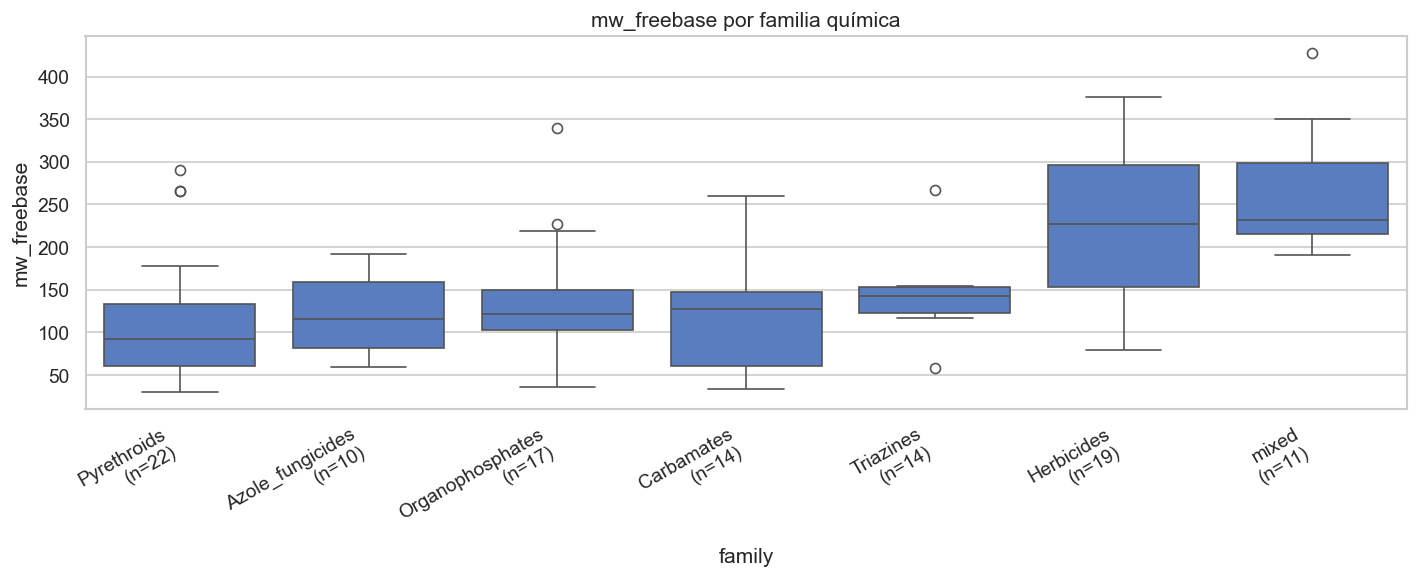

C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


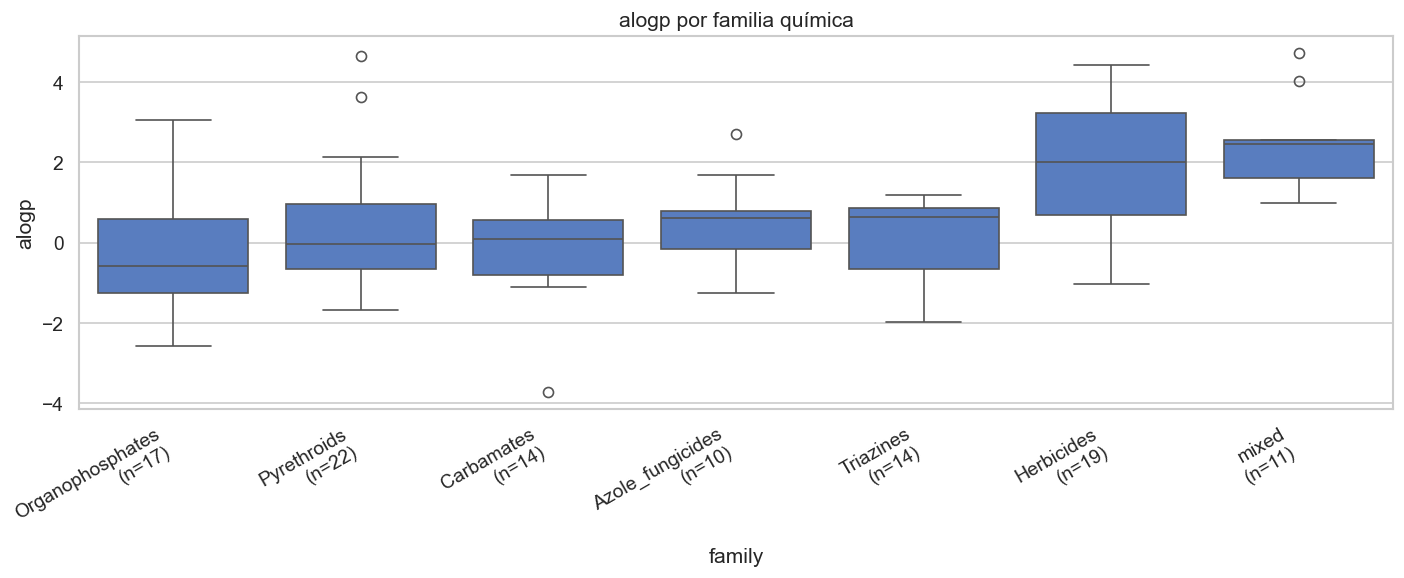

C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


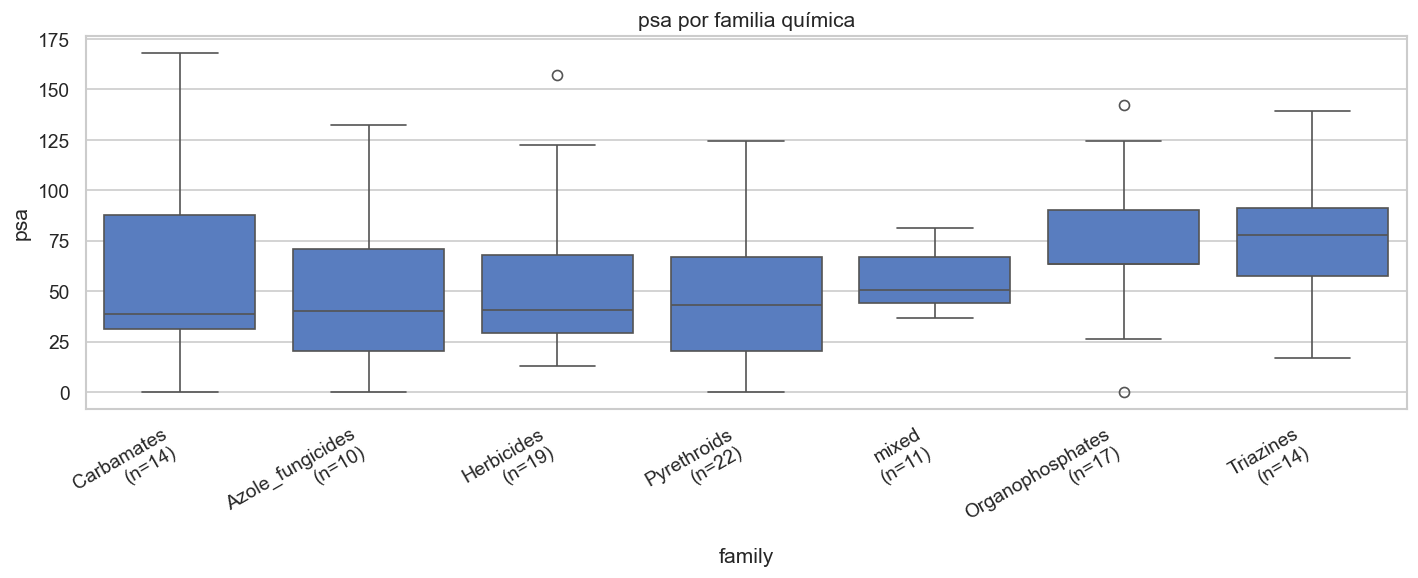

C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


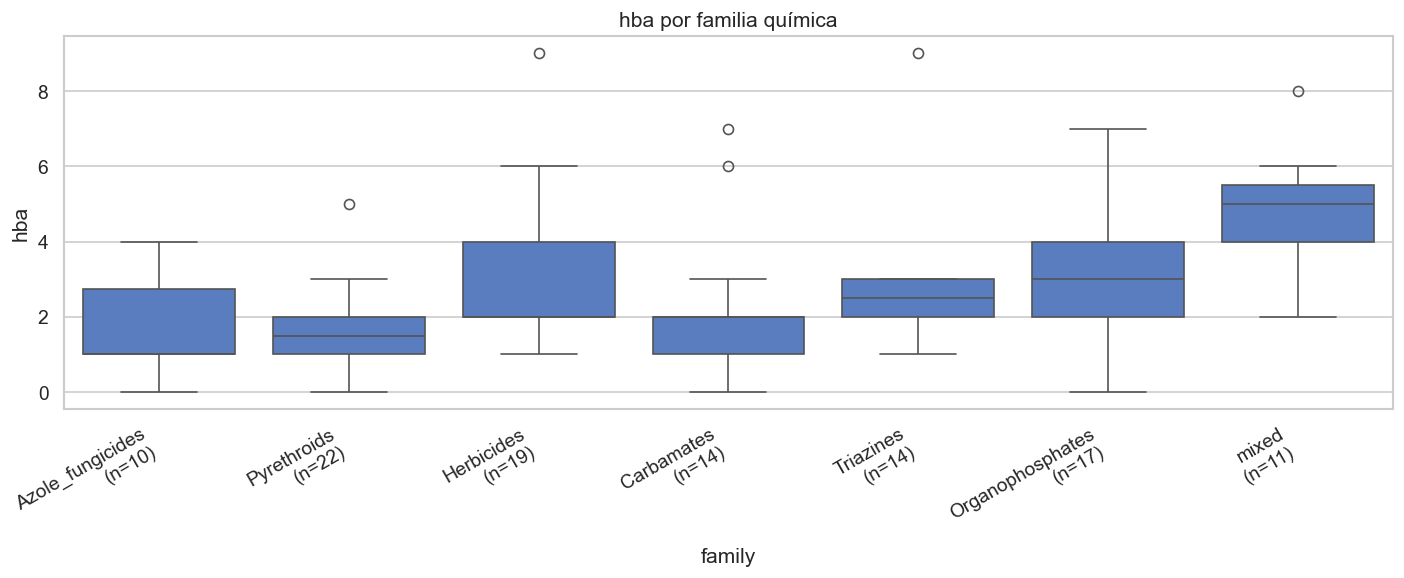

C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


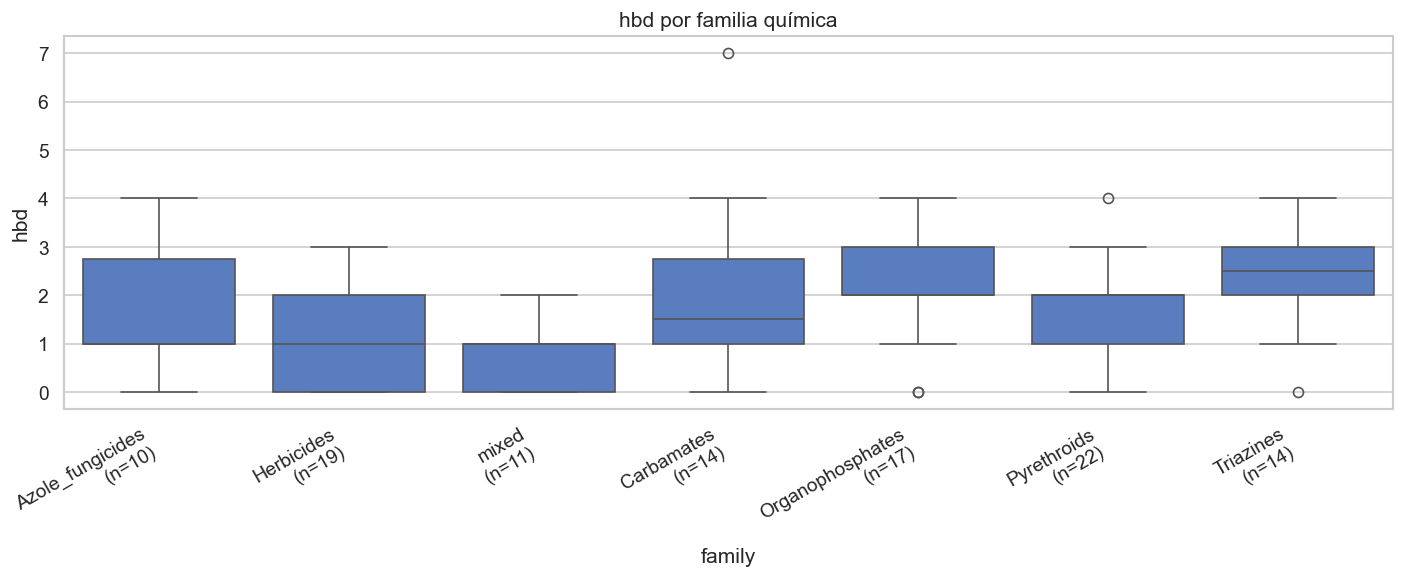

C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


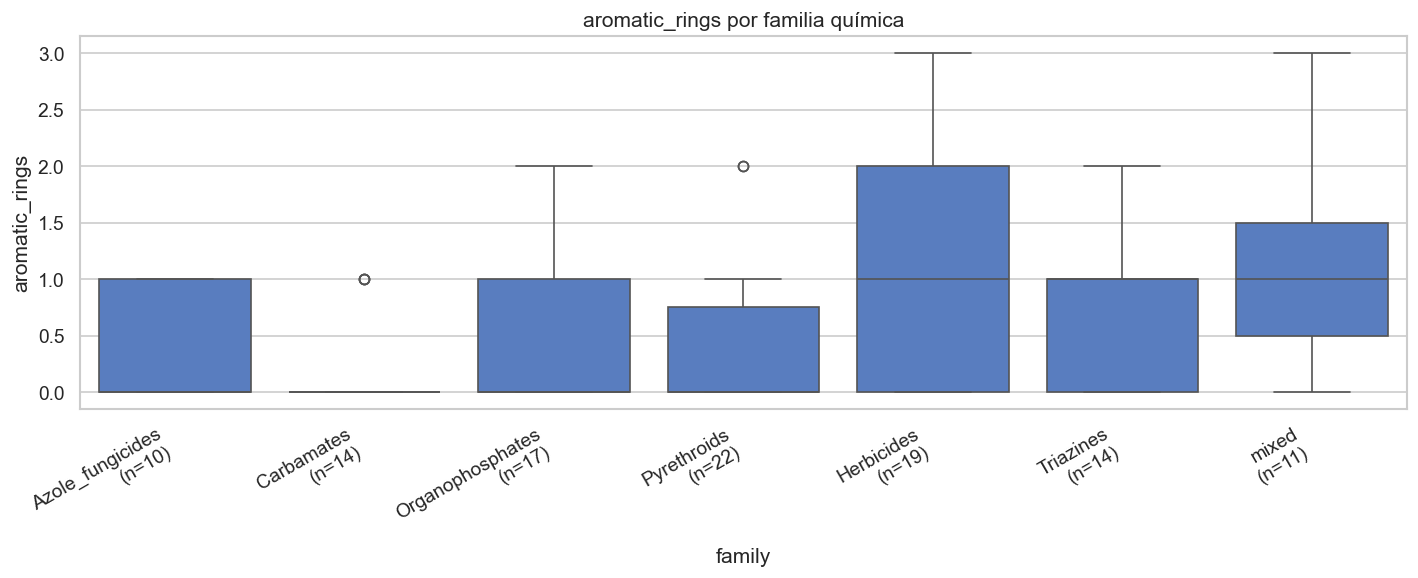

C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


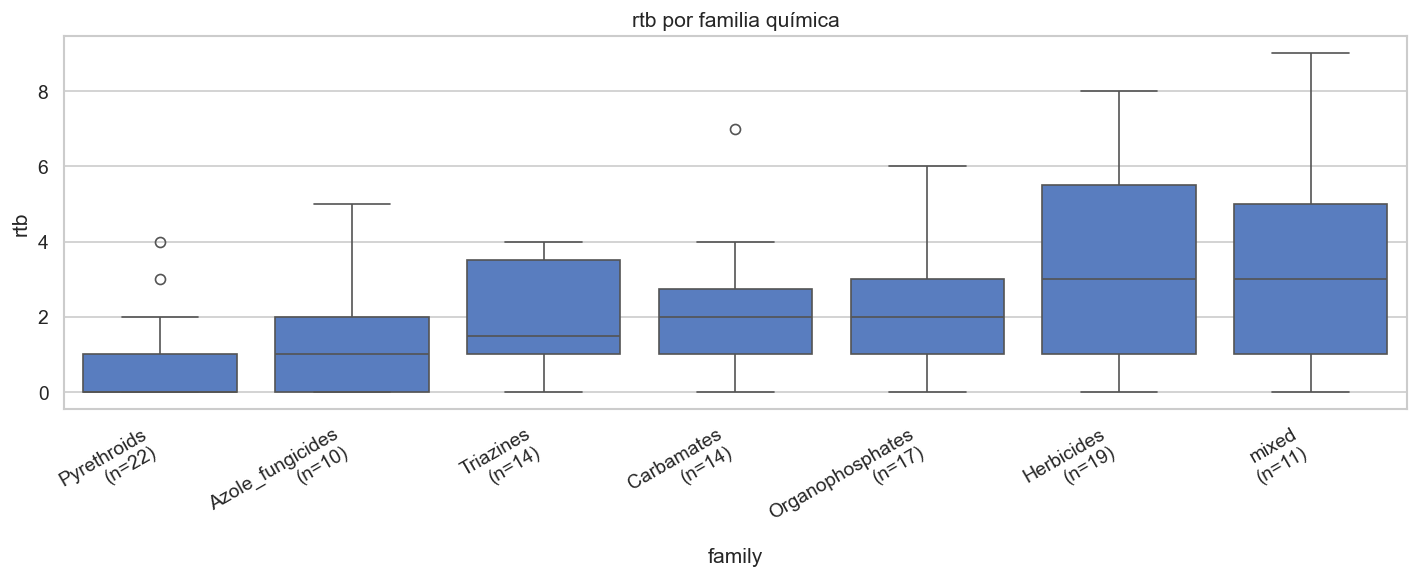

C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


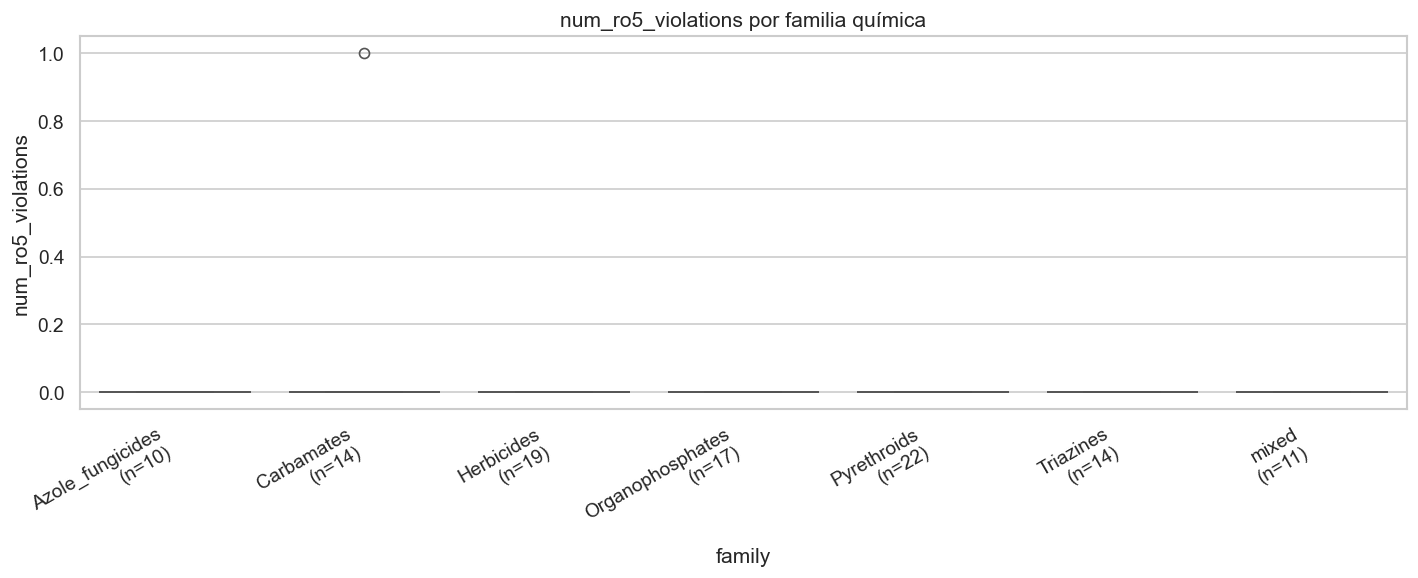

C:\Users\mateo\AppData\Local\Temp\ipykernel_47064\4056731135.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30, ha="right")


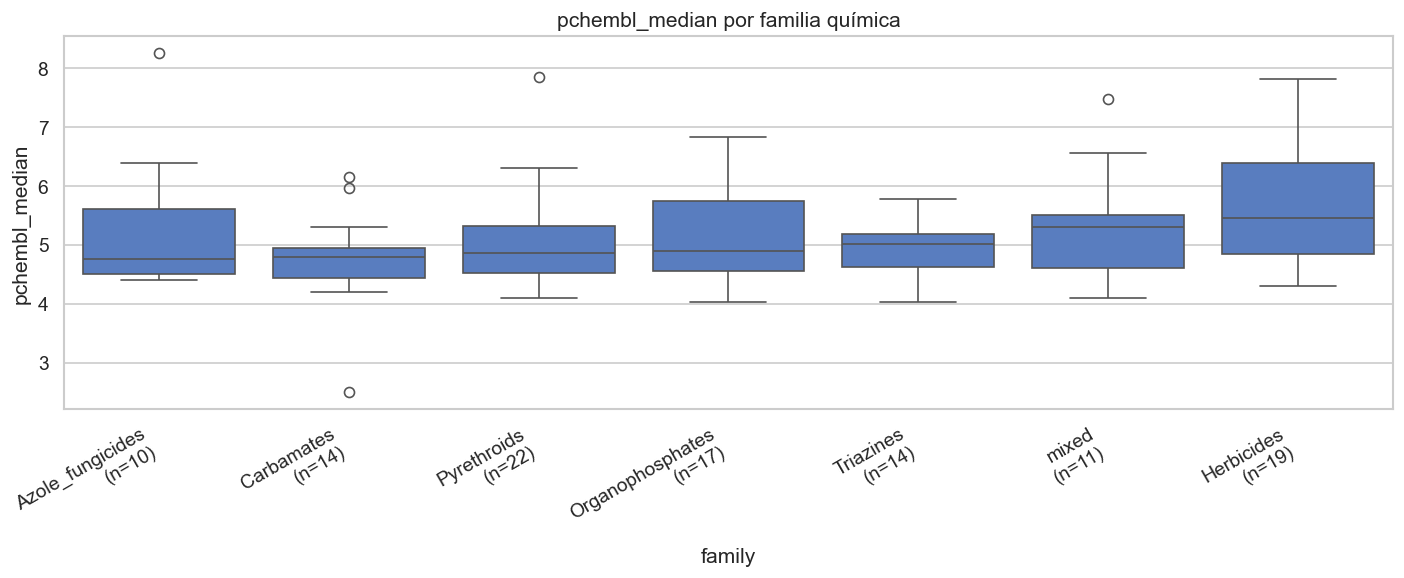

Advertencia: familias con n<5 compuestos tienen comparaciones poco estables.


In [ ]:
family_counts = compounds["family"].value_counts()

for col in FEATURE_COLS + ["pchembl_median"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    order = compounds.groupby("family")[col].median().sort_values().index
    sns.boxplot(data=compounds, x="family", y=col, order=order, ax=ax)
    labels = [f"{f}\n(n={family_counts[f]})" for f in order]
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(f"{col} por familia química")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"box_{col}_by_family.png", bbox_inches="tight")
    plt.show()

print("Advertencia: familias con n<5 compuestos tienen comparaciones poco estables.")


**Conclusión:** Hay diferencias visuales entre familias en lipofilia, tamaño y anillos aromáticos — esperables por definición química. Familias con n bajo producen cajas inestables: no interpretar esas diferencias como hallazgo causal sin tests formales.


## 3. Promiscuidad y perfil de dianas

**Descripción:** Histograma y boxplot de `n_targets` por compuesto/familia, y heatmap compuesto × `target_type` para ver el perfil de dianas ensayadas.


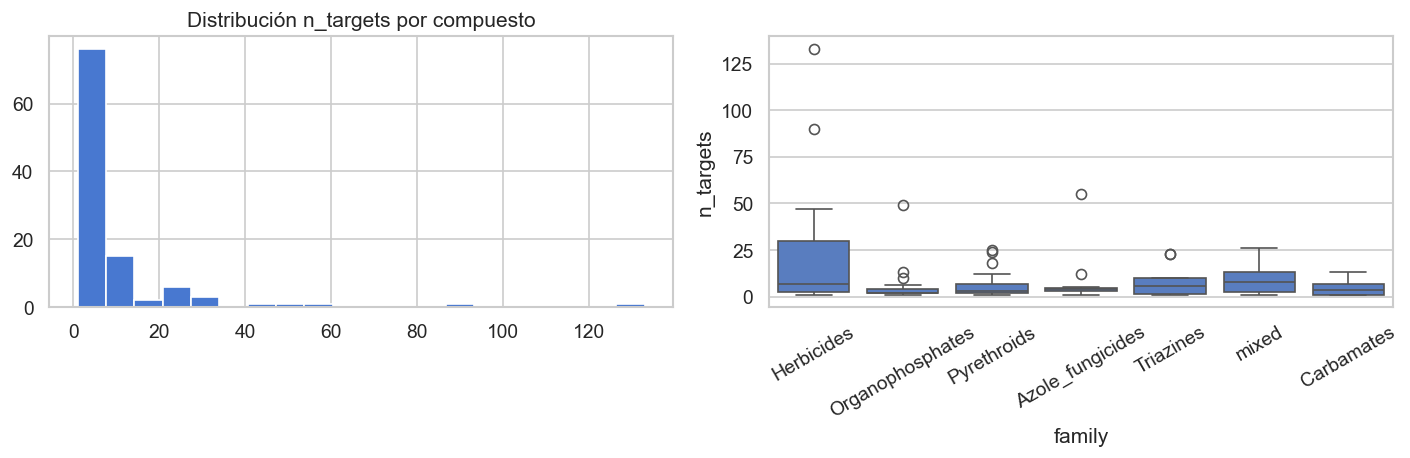

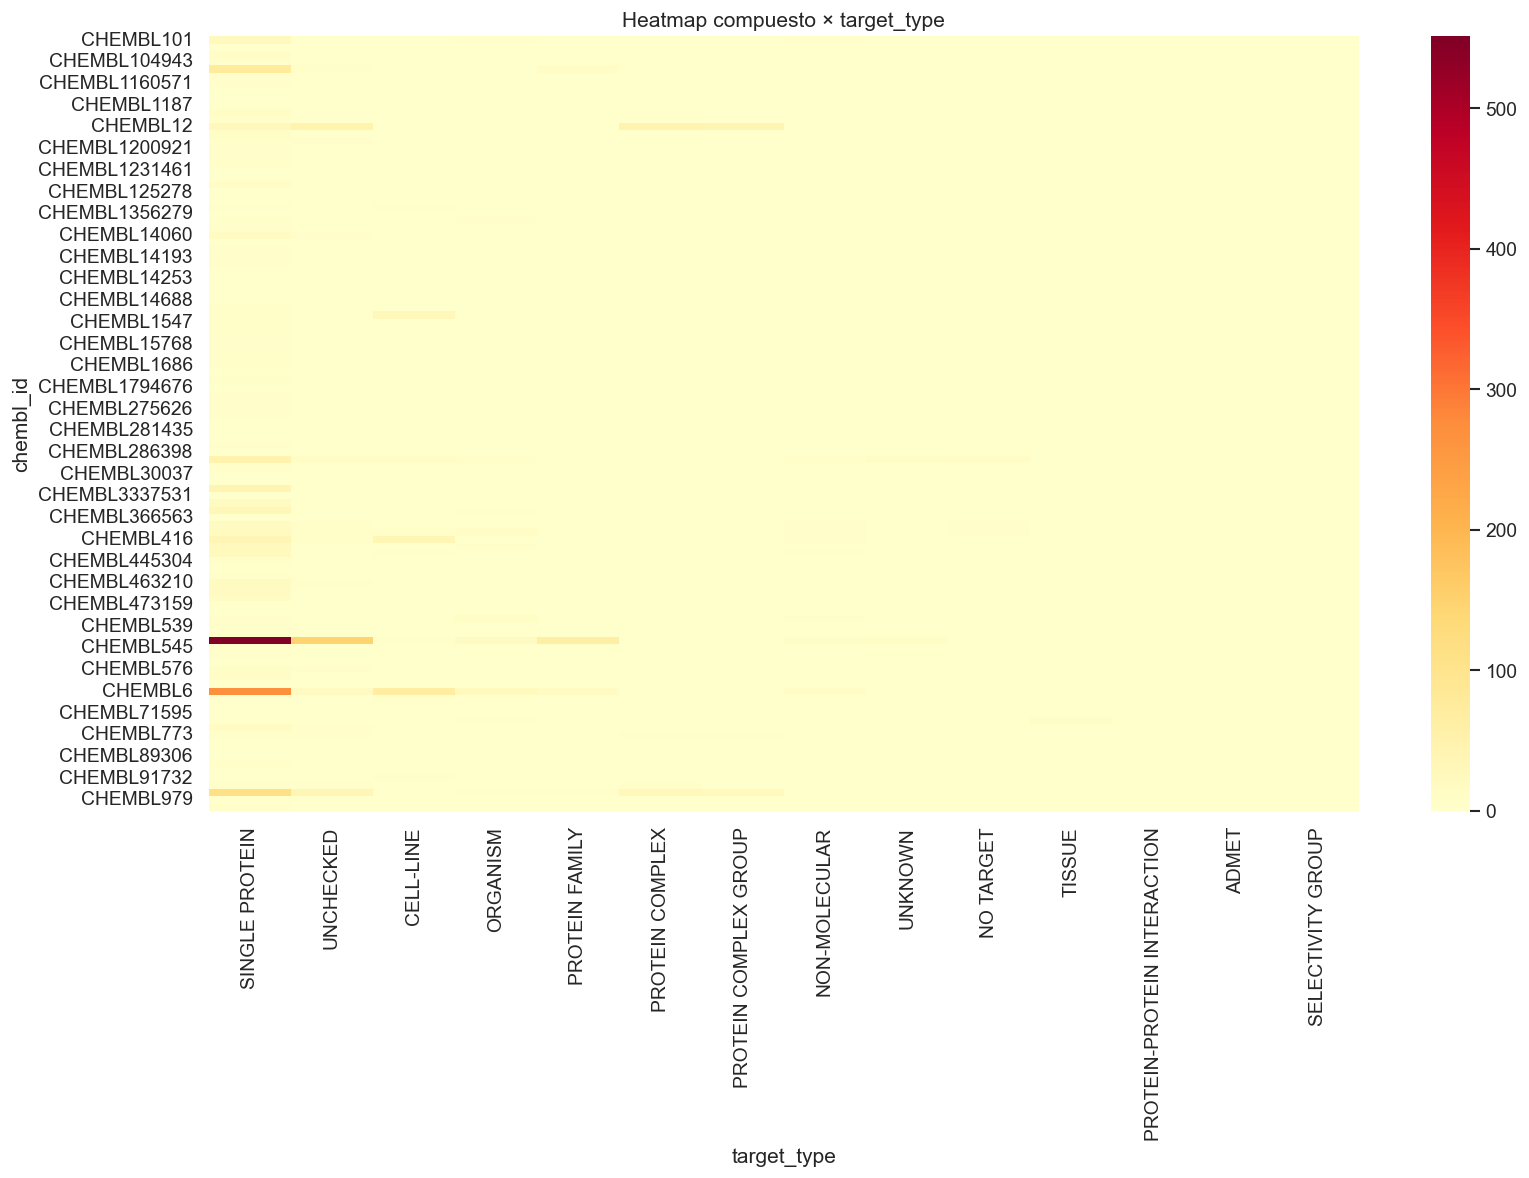

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
compounds["n_targets"].hist(bins=20, ax=axes[0], edgecolor="white")
axes[0].set_title("Distribución n_targets por compuesto")
sns.boxplot(data=compounds, x="family", y="n_targets", ax=axes[1])
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "promiscuity_distribution.png", bbox_inches="tight")
plt.show()

if "target_type" in activities.columns:
    ct = pd.crosstab(activities["chembl_id"], activities["target_type"])
    top = ct.sum(axis=0).nlargest(15).index
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(ct[top], cmap="YlOrRd", ax=ax)
    ax.set_title("Heatmap compuesto × target_type")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "heatmap_compound_target.png", bbox_inches="tight")
    plt.show()


**Conclusión:** La promiscuidad (n_targets) es heterogénea: pocos compuestos tocan muchas dianas. El heatmap muestra que el perfil experimental no es uniforme entre moléculas — otra razón para no tratar cada fila de actividad como observación i.i.d.


## 4. Perfil de endpoints

**Descripción:** Contar `standard_type` y `standard_relation` en la tabla de mediciones para documentar la heterogeneidad de endpoints y la censura residual.

Hay **múltiples `standard_type`** (Ki, IC50, EC50, …). Por eso **no** se agrupa `pchembl_value` crudo como target único de regresión.


In [ ]:
if "standard_type" in activities.columns:
    display(activities["standard_type"].value_counts().to_frame("n_filas"))

if "standard_relation" in activities.columns:
    print("Relaciones de censura en mediciones:")
    display(activities["standard_relation"].value_counts(dropna=False).to_frame("n"))


,n_filas
standard_type,
IC50,1013
Ki,886
Potency,503
EC50,158
AC50,124
Kd,62
MIC,39
ED50,10
LD50,4


Relaciones de censura en mediciones:


,n
standard_relation,
=,2807


**Conclusión:** IC50 y Ki dominan; hay endpoints minoritarios (LD50, MIC, …) no comparables. Si en este corte `standard_relation` aparece homogéneo, la censura ya fue filtrada/agregada aguas arriba — igual se mantiene la regla: no mezclar endpoints heterogéneos en un solo modelo de potencia.


## 5. Correlación honesta (pchembl_median a nivel compuesto)

**Descripción:** Calcular Pearson/Spearman de descriptores vs `pchembl_median`, heatmap de correlación y pairplot en el nivel compuesto (sin fuga por filas repetidas).


,variable,pearson,spearman,n
5,aromatic_rings,0.1894,0.2076,107
1,alogp,0.1256,0.1887,107
7,num_ro5_violations,-0.0908,-0.1384,107
0,mw_freebase,0.1846,0.1307,107
4,hbd,-0.1414,-0.1263,107
3,hba,0.1494,0.1194,107
6,rtb,0.1325,0.0997,107
2,psa,0.0304,0.0141,107


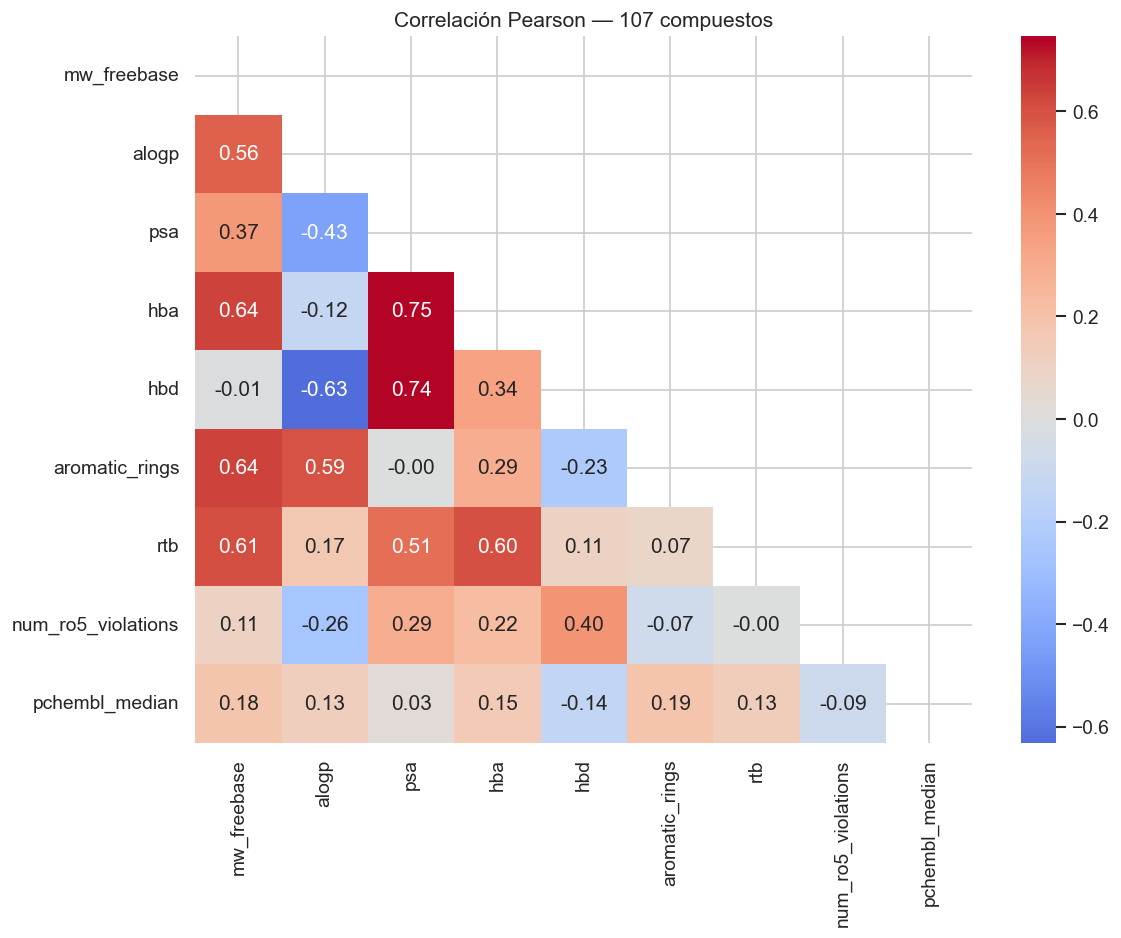

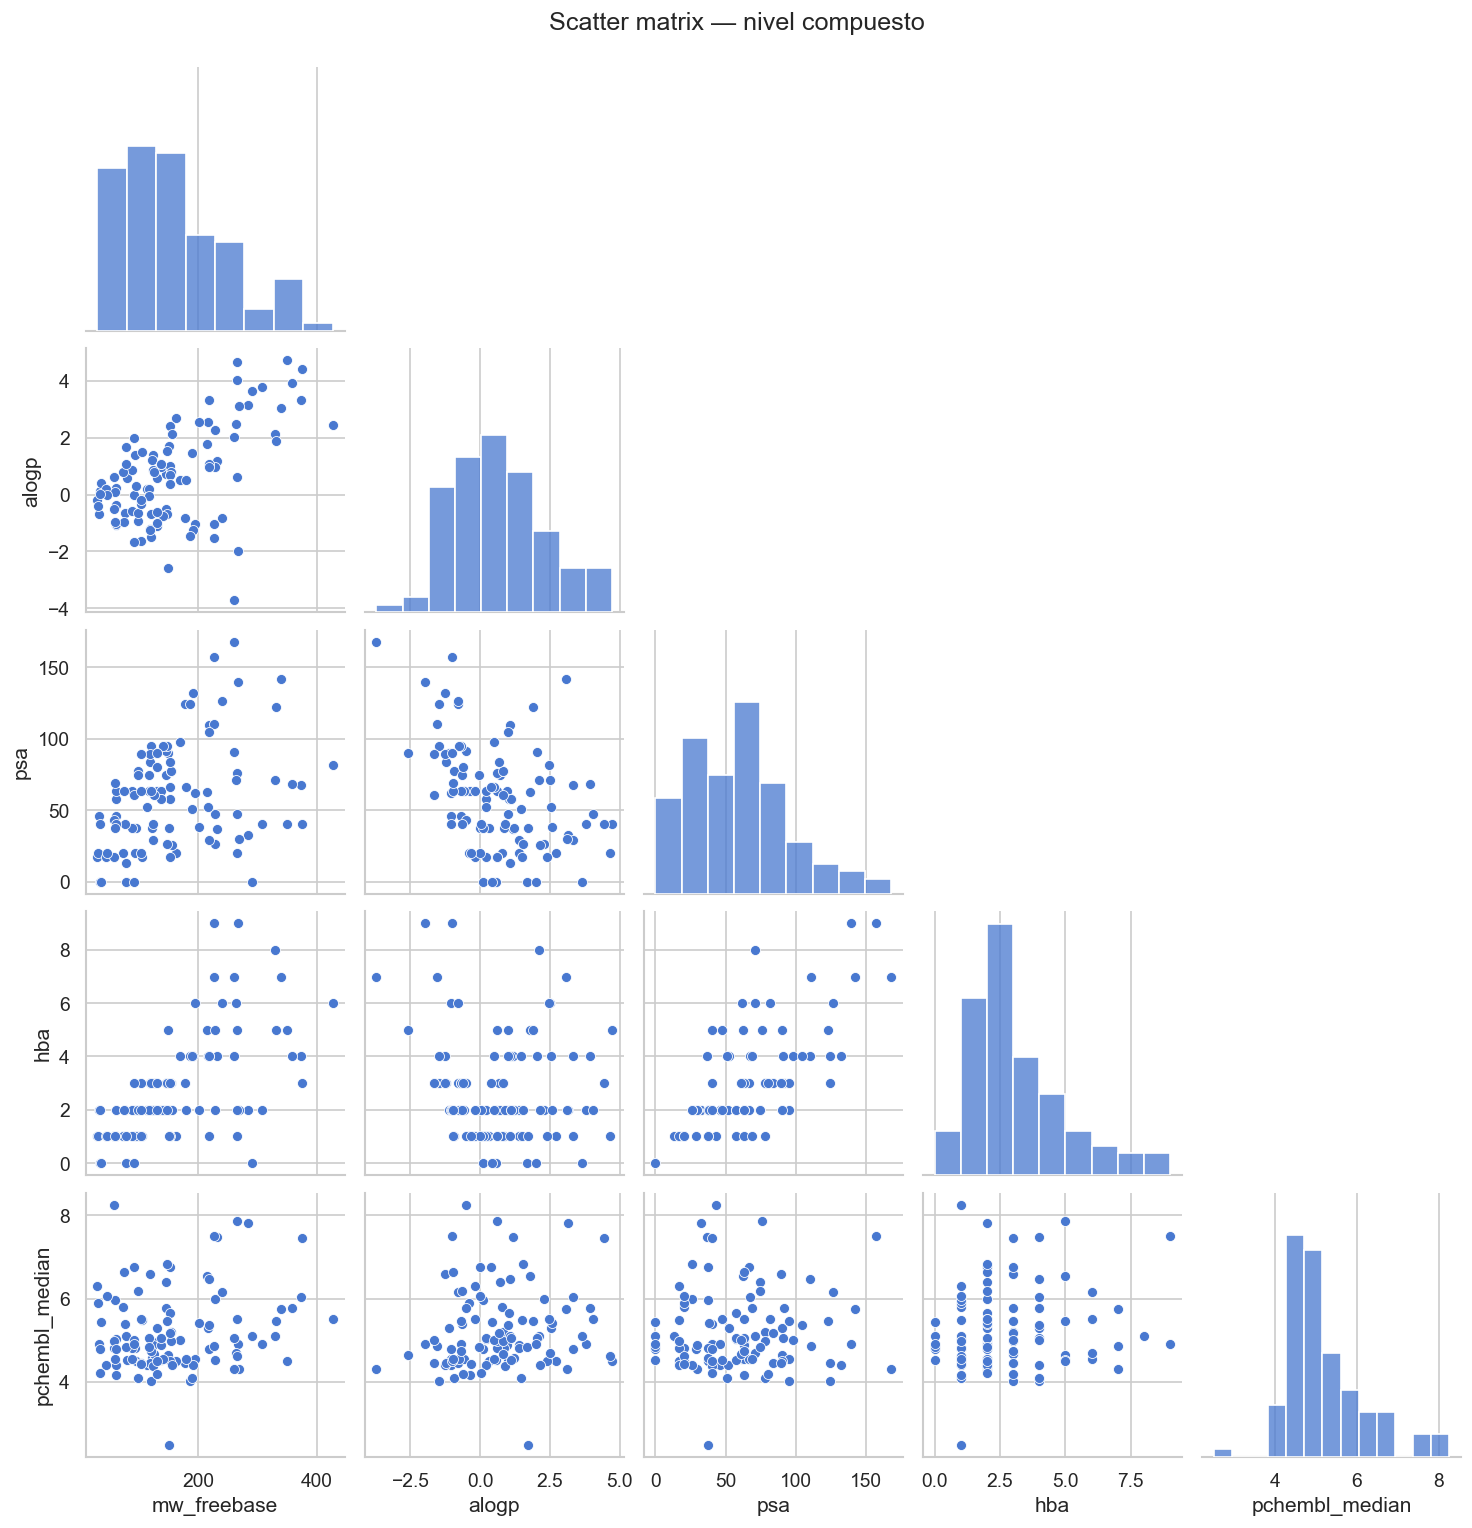

In [ ]:
corr_table = correlation_with_target(compounds, target="pchembl_median", columns=FEATURE_COLS)
display(corr_table.round(4))

corr_matrix = compounds[FEATURE_COLS + ["pchembl_median"]].corr(method="pearson")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación Pearson — 107 compuestos")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

pair_cols = FEATURE_COLS[:4] + ["pchembl_median"]
g = sns.pairplot(compounds[pair_cols].dropna(), diag_kind="hist", corner=True)
g.fig.suptitle("Scatter matrix — nivel compuesto", y=1.02)
g.savefig(FIG_DIR / "correlation_pairplot.png", bbox_inches="tight")
plt.show()


**Conclusión:** Las correlaciones con potencia son **débiles** (|r| ≲ 0.2). Hay colinealidad entre descriptores (útil para PCA). Con esta señal lineal limitada, un baseline clásico sobre descriptores 2D no debería esperarse muy predictivo (se confirma en Fase 4 / P6).
